# **Set Up**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/UFC Project"
os.chdir(PROJECT_PATH)

!pwd

/content/drive/MyDrive/Colab Notebooks/UFC Project


In [18]:
import pandas as pd

fighters = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/UFC Project/data/raw/raw_fighters.csv")
fights = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/UFC Project/data/raw/raw_fights_detailed.csv")

In [5]:
!pip install mlflow
!pip install pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existi

In [7]:
import mlflow
import subprocess
from pyngrok import ngrok, conf
import getpass

In [14]:
MLFLOW_TRACKING_URI = "/content/drive/MyDrive/Colab Notebooks/UFC_Project/mlruns"
subprocess.Popen(["mlflow", "ui", "--backend-store-uri", MLFLOW_TRACKING_URI])

<Popen: returncode: None args: ['mlflow', 'ui', '--backend-store-uri', '/con...>

In [15]:
mlflow.set_experiment("UFC_Fighter_Clustering")

<Experiment: artifact_location='/content/drive/MyDrive/Colab Notebooks/UFC Project/mlruns/1', creation_time=1771083127255, experiment_id='1', last_update_time=1771083127255, lifecycle_stage='active', name='UFC_Fighter_Clustering', tags={}>

In [10]:
# ── Plot style ───────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': '#1a1a2e',
                     'axes.facecolor': '#16213e', 'axes.labelcolor': 'white',
                     'xtick.color': 'white', 'ytick.color': 'white',
                     'text.color': 'white', 'axes.titlecolor': 'white',
                     'grid.color': '#2a2a4a'})
ACCENT = '#e94560'
GOLD   = '#f5a623'

print('✅ Libraries loaded')

✅ Libraries loaded


In [16]:
OUTPUT_DIR = PROJECT_PATH + '/data/processed/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# **Data Check**

In [20]:
print(f'fighters : {fighters.shape}')
print(f'fights   : {fights.shape}')

fighters : (4448, 12)
fights   : (8482, 55)


# **fonctions d'aide**


> Les fonctions permettent de transformer les valeurs des attributs non numériques.


In [21]:
def parse_of(s):
    """
    '134 of 383'  →  (134.0, 383.0)
    '---' or NaN  →  (NaN, NaN)
    """
    try:
        parts = str(s).split(' of ')
        return float(parts[0]), float(parts[1])
    except:
        return np.nan, np.nan


def parse_pct(s):
    """
    '47%'  →  0.47
    '---'  →  NaN
    """
    try:
        return float(str(s).replace('%', '')) / 100
    except:
        return np.nan


def parse_ctrl(s):
    """
    '5:12'  →  312  (seconds)
    """
    try:
        m, sec = str(s).split(':')
        return int(m) * 60 + int(sec)
    except:
        return np.nan


def parse_fight_time(s):
    """
    '4:35'  →  275  (seconds in the final round)
    """
    try:
        m, sec = str(s).split(':')
        return int(m) * 60 + int(sec)
    except:
        return np.nan


def parse_height(h):
    """
    "5' 11\""  →  71  (inches)
    """
    try:
        parts = str(h).replace('"', '').split("'")
        return int(parts[0]) * 12 + int(parts[1].strip())
    except:
        return np.nan


def parse_reach(r):
    """
    '72.0"'  →  72.0
    """
    try:
        return float(str(r).replace('"', ''))
    except:
        return np.nan


def parse_weight(w):
    """
    '155 lbs.'  →  155
    """
    try:
        return int(str(w).replace(' lbs.', ''))
    except:
        return np.nan


print('✅ Parsing functions ready')

✅ Parsing functions ready


# **Parsing the raw_fight_dataset**

In [22]:
f = fights.copy()

# ── Total fight duration ──────────────────────────────────────
# (rounds completed × 5 min) + time in the final round
f['fight_sec']       = f['Fight_Time'].apply(parse_fight_time)
f['total_fight_sec'] = (f['Round'] - 1) * 300 + f['fight_sec']
f['total_fight_min'] = f['total_fight_sec'] / 60

# ── Method group (broad finish category) ─────────────────────
f['method_group'] = (
    f['Method']
    .str.extract(r'^(KO/TKO|SUB|U-DEC|S-DEC|M-DEC)', expand=False)
    .fillna('Other')
)

print('✅ Fight-level columns parsed')
print(f['total_fight_min'].describe().round(2))

✅ Fight-level columns parsed
count    8482.00
mean       10.56
std         6.06
min         0.08
25%         4.63
50%        13.40
75%        15.00
max        25.00
Name: total_fight_min, dtype: float64


# **Mixing Les datasets ensemble**

In [25]:
def extract_fighter_side(df, side):
    """
    Extract all stats for fighter on 'side' (1 or 2) into a
    standardised DataFrame with consistent column names.
    """
    n = str(side)

    # Columns that are 'X of Y' format
    of_map = {
        f'Sig. Str._{n}' : ('sig_str_landed', 'sig_str_att'),
        f'Total Str._{n}': ('total_str_landed','total_str_att'),
        f'Td_{n}'        : ('td_landed',       'td_att'),
        f'Head_{n}'      : ('head_landed',      'head_att'),
        f'Body_{n}'      : ('body_landed',      'body_att'),
        f'Leg_{n}'       : ('leg_landed',       'leg_att'),
        f'Distance_{n}'  : ('dist_landed',      'dist_att'),
        f'Clinch_{n}'    : ('clinch_landed',    'clinch_att'),
        f'Ground_{n}'    : ('ground_landed',    'ground_att'),
    }

    rows = pd.DataFrame()
    rows['Fighter_Id']      = df[f'Fighter_Id_{n}']
    rows['Fighter_Name']    = df[f'Fighter_{n}']
    rows['total_fight_min'] = df['total_fight_min']
    rows['method_group']    = df['method_group']
    rows['result']          = df[f'Result_{n}']
    rows['kd']              = df[f'Kd_{n}']
    rows['sub_att']         = df[f'Sub. Att_{n}']
    rows['ctrl_sec']        = df[f'Ctrl_{n}'].apply(parse_ctrl)
    rows['sig_str_pct']     = df[f'Sig. Str. %_{n}'].apply(parse_pct)
    rows['td_pct']          = df[f'Td %_{n}'].apply(parse_pct)

    for col, (lname, aname) in of_map.items():
        parsed      = df[col].apply(parse_of)
        rows[lname] = parsed.apply(lambda x: x[0])
        rows[aname] = parsed.apply(lambda x: x[1])

    return rows


f1      = extract_fighter_side(f, 1)
f2      = extract_fighter_side(f, 2)
long_df = pd.concat([f1, f2], ignore_index=True)

print(f'✅ Stacked shape: {long_df.shape}  ')
print(f'   Unique fighters: {long_df["Fighter_Id"].nunique()}')
long_df.head(3)

✅ Stacked shape: (16964, 28)  
   Unique fighters: 2638


,Fighter_Id,Fighter_Name,total_fight_min,method_group,result,kd,sub_att,ctrl_sec,sig_str_pct,td_pct,...,body_landed,body_att,leg_landed,leg_att,dist_landed,dist_att,clinch_landed,clinch_att,ground_landed,ground_att
0,d661ce4da776fc20,Merab Dvalishvili,25.000000,U-DEC,L,0.0,2.0,312.0,0.34,0.06,...,22.0,34.0,7.0,8.0,116.0,353.0,18.0,30.0,0.0,0.0
1,17e97649403ba428,Alexandre Pantoja,0.433333,KO/TKO,L,0.0,0.0,0.0,0.54,NaN,...,1.0,1.0,1.0,2.0,5.0,10.0,1.0,1.0,0.0,0.0
2,4461d7e47375a895,Brandon Moreno,7.400000,KO/TKO,L,0.0,1.0,5.0,0.52,NaN,...,0.0,2.0,1.0,1.0,7.0,15.0,0.0,0.0,2.0,2.0


# **Filtre par le nombre du combats par combateur :**

> Les combattants ayant très peu de combats présentent des moyennes irrégulières qui perturbent le regroupement.

Nous ne conservons dans l'ensemble de données que les combattants ayant **≥ 5 combats**.



In [26]:
MIN_FIGHTS = 5

fight_counts = long_df.groupby('Fighter_Id')['sig_str_landed'].count()
valid_fighters = fight_counts[fight_counts >= MIN_FIGHTS].index

long_filtered = long_df[long_df['Fighter_Id'].isin(valid_fighters)].copy()

print(f'MIN_FIGHTS = {MIN_FIGHTS}')
print(f'Fighters before filter : {long_df["Fighter_Id"].nunique()}')
print(f'Fighters after  filter : {long_filtered["Fighter_Id"].nunique()}')
print(f'Rows remaining         : {len(long_filtered)}')

MIN_FIGHTS = 5
Fighters before filter : 2638
Fighters after  filter : 1222
Rows remaining         : 13621


# **Core Style Features**

In [28]:
 #── Sum everything at fighter level first ─────────────────────
agg = long_filtered.groupby(['Fighter_Id', 'Fighter_Name']).agg(
    n_fights             = ('sig_str_landed',   'count'),
    total_fight_min      = ('total_fight_min',  'sum'),
    sig_str_landed_sum   = ('sig_str_landed',   'sum'),
    sig_str_att_sum      = ('sig_str_att',      'sum'),
    total_str_landed_sum = ('total_str_landed', 'sum'),
    td_landed_sum        = ('td_landed',        'sum'),
    td_att_sum           = ('td_att',           'sum'),
    sub_att_sum          = ('sub_att',          'sum'),
    kd_sum               = ('kd',               'sum'),
    ctrl_sec_sum         = ('ctrl_sec',         'sum'),
    head_landed_sum      = ('head_landed',      'sum'),
    body_landed_sum      = ('body_landed',      'sum'),
    leg_landed_sum       = ('leg_landed',       'sum'),
    dist_landed_sum      = ('dist_landed',      'sum'),
    clinch_landed_sum    = ('clinch_landed',    'sum'),
    ground_landed_sum    = ('ground_landed',    'sum'),
).reset_index()

print(f'✅ Aggregated to {len(agg)} fighters')
agg.head(3)

✅ Aggregated to 6125 fighters


,Fighter_Id,Fighter_Name,n_fights,total_fight_min,sig_str_landed_sum,sig_str_att_sum,total_str_landed_sum,td_landed_sum,td_att_sum,sub_att_sum,kd_sum,ctrl_sec_sum,head_landed_sum,body_landed_sum,leg_landed_sum,dist_landed_sum,clinch_landed_sum,ground_landed_sum
0,0052de90691d4a93,Arman Tsarukyan,1,15.000000,91.0,197.0,118.0,1.0,5.0,0.0,0.0,188.0,60.0,13.0,18.0,80.0,6.0,5.0
1,0052de90691d4a93,Chris Gruetzemacher,1,10.833333,46.0,97.0,57.0,0.0,0.0,0.0,0.0,14.0,25.0,10.0,11.0,39.0,4.0,3.0
2,0052de90691d4a93,Davi Ramos,5,51.200000,115.0,311.0,155.0,5.0,11.0,2.0,0.0,505.0,78.0,17.0,20.0,86.0,7.0,22.0


---
#**Calcul des caractéristiques de taux et de ratio**
Les totaux bruts n'ont aucun sens pour des combattants ayant des carrières de durées différentes. Nous convertissons tout en **taux** (par minute / par combat) et en **ratios** (proportion du nombre total de coups).

In [29]:
# ── Volume rates ──────────────────────────────────────────────
agg['sig_str_pm']        = agg['sig_str_landed_sum']  / agg['total_fight_min']
agg['td_per_fight']      = agg['td_landed_sum']       / agg['n_fights']
agg['sub_per_fight']     = agg['sub_att_sum']         / agg['n_fights']
agg['kd_per_fight']      = agg['kd_sum']              / agg['n_fights']
agg['ctrl_sec_per_fight']= agg['ctrl_sec_sum']        / agg['n_fights']

# ── Accuracy rates ────────────────────────────────────────────
# Replace 0 attempts with NaN to avoid divide-by-zero
agg['sig_str_accuracy']  = (
    agg['sig_str_landed_sum'] /
    agg['sig_str_att_sum'].replace(0, np.nan)
)
agg['td_accuracy']       = (
    agg['td_landed_sum'] /
    agg['td_att_sum'].replace(0, np.nan)
)

# ── Strike location ratios (by target) ───────────────────────
# What proportion of sig strikes went to head / body / leg?
sig_denom = agg['sig_str_landed_sum'].replace(0, np.nan)
agg['head_ratio']    = agg['head_landed_sum']   / sig_denom
agg['body_ratio']    = agg['body_landed_sum']   / sig_denom
agg['leg_ratio']     = agg['leg_landed_sum']    / sig_denom

# ── Strike range ratios (by position) ────────────────────────
# What proportion of sig strikes came from distance / clinch / ground?
agg['dist_ratio']    = agg['dist_landed_sum']   / sig_denom
agg['clinch_ratio']  = agg['clinch_landed_sum'] / sig_denom
agg['ground_ratio']  = agg['ground_landed_sum'] / sig_denom

print('✅ Rate and ratio features computed')
rate_cols = ['sig_str_pm','sig_str_accuracy','td_per_fight','td_accuracy',
             'sub_per_fight','kd_per_fight','ctrl_sec_per_fight',
             'head_ratio','body_ratio','leg_ratio',
             'dist_ratio','clinch_ratio','ground_ratio']
print(agg[rate_cols].describe().round(3))

✅ Rate and ratio features computed
       sig_str_pm  sig_str_accuracy  td_per_fight  td_accuracy  sub_per_fight  \
count    6125.000          6109.000      6125.000     4355.000       6125.000   
mean        3.942             0.460         1.023        0.379          0.327   
std         3.084             0.142         1.541        0.325          0.669   
min         0.000             0.000         0.000        0.000          0.000   
25%         2.222             0.373         0.000        0.000          0.000   
50%         3.400             0.456         0.333        0.333          0.000   
75%         4.867             0.541         1.400        0.558          0.400   
max        51.429             1.000        12.000        1.000          7.000   

       kd_per_fight  ctrl_sec_per_fight  head_ratio  body_ratio  leg_ratio  \
count      6125.000            6125.000    6053.000    6053.000   6053.000   
mean          0.222             124.332       0.618       0.207      0.175   
s

---
# . **Analyse des  KO/TKO finition par Fighter**

Pour chaque combattant : quel pourcentage de ses combats se sont terminés par KO/TKO, soumission ou décision ? Cela permet de déterminer si un combattant est un finisseur ou un accumulateur de points.

In [30]:
finish_agg = (
    long_filtered
    .groupby('Fighter_Id')
    .apply(lambda x: pd.Series({
        'ko_rate'  : (x['method_group'] == 'KO/TKO').sum() / len(x),
        'sub_rate' : (x['method_group'] == 'SUB').sum()    / len(x),
        'dec_rate' : (x['method_group'].isin(['U-DEC','S-DEC','M-DEC'])).sum() / len(x),
        'win_rate' : (x['result'] == 'W').sum() / len(x),
    }))
    .reset_index()
)

agg = agg.merge(finish_agg, on='Fighter_Id', how='left')

print('✅ Finish tendency features merged')
print(agg[['ko_rate','sub_rate','dec_rate','win_rate']].describe().round(3))

✅ Finish tendency features merged
        ko_rate  sub_rate  dec_rate  win_rate
count  6125.000  6125.000  6125.000  6125.000
mean      0.317     0.182     0.490     0.515
std       0.195     0.155     0.210     0.187
min       0.000     0.000     0.000     0.000
25%       0.167     0.062     0.333     0.400
50%       0.300     0.158     0.500     0.529
75%       0.429     0.273     0.636     0.647
max       1.000     1.000     1.000     1.000


# **Fusion des attributs physiques**
Regroupement des données de profil des combattants (taille, allonge, catégorie de poids, position).

Décision de conception : L’allonge -Reach-(44 % de données manquantes) et la taille (7 % de données manquantes) sont exclues du regroupement par attributs, car elles présentent trop d’écarts. La catégorie de poids est conservée comme colonne de contexte, mais ne sera PAS utilisée comme critère de regroupement (afin d’éviter les regroupements basés uniquement sur le poids). La position est conservée et encodée en one-hot.

In [31]:
# ── Parse physical attributes ─────────────────────────────────
fighters_clean = fighters.copy()
fighters_clean['height_in']  = fighters_clean['Ht.'].replace('--', np.nan).apply(parse_height)
fighters_clean['reach_in']   = fighters_clean['Reach'].replace('--', np.nan).apply(parse_reach)
fighters_clean['weight_lbs'] = fighters_clean['Wt.'].apply(parse_weight)
fighters_clean['total_record']= fighters_clean['W'] + fighters_clean['L'] + fighters_clean['D']

profile_cols = ['Fighter_Id','Stance','weight_lbs','height_in','reach_in']
agg = agg.merge(
    fighters_clean[profile_cols],
    on='Fighter_Id',
    how='left'
)

# ── One-hot encode Stance ─────────────────────────────────────
# Keep Orthodox, Southpaw, Switch — group rare stances as 'Other'
agg['Stance_clean'] = agg['Stance'].where(
    agg['Stance'].isin(['Orthodox','Southpaw','Switch']), 'Other'
)
stance_dummies = pd.get_dummies(agg['Stance_clean'], prefix='stance').astype(int)
agg = pd.concat([agg, stance_dummies], axis=1)

print(f'✅ Physical attributes merged. Shape: {agg.shape}')
print(agg[['Stance','weight_lbs','height_in']].describe().round(2))

✅ Physical attributes merged. Shape: (6125, 44)
       weight_lbs  height_in
count     6125.00    6125.00
mean       164.63      70.09
std         34.92       3.59
min        115.00      60.00
25%        135.00      67.00
50%        155.00      70.00
75%        185.00      73.00
max        300.00      83.00


---
# **Gestion des valeurs manquantes**

Stratégie par colonne :

- **`td_accuracy`** — NaN signifie que le combattant n'a jamais tenté de projection Takedown → remplacer par **0**

- **Stance dummies** — position manquante → déjà enregistrée comme `stance_Other`

- **`weight_lbs`** — remplacer par la **médiane** (seuls quelques combattants ne possèdent pas cette valeur)

In [32]:
# ── Define final feature columns ──────────────────────────────
STYLE_FEATURES = [
    # Volume
    'sig_str_pm',
    'td_per_fight',
    'sub_per_fight',
    'kd_per_fight',
    'ctrl_sec_per_fight',
    # Accuracy
    'sig_str_accuracy',
    'td_accuracy',
    # Strike target ratios
    'head_ratio',
    'body_ratio',
    'leg_ratio',
    # Strike range ratios
    'dist_ratio',
    'clinch_ratio',
    'ground_ratio',
    # Finish tendencies
    'ko_rate',
    'sub_rate',
    'dec_rate',
    'win_rate',
]

# ── Missing value fixes ───────────────────────────────────────
print('Missing values BEFORE:')
print(agg[STYLE_FEATURES].isnull().sum()[agg[STYLE_FEATURES].isnull().sum() > 0])

# td_accuracy: never attempted a TD → 0 accuracy
agg['td_accuracy'] = agg['td_accuracy'].fillna(0)

# weight_lbs: fill with median
agg['weight_lbs'] = agg['weight_lbs'].fillna(agg['weight_lbs'].median())

print('\nMissing values AFTER:')
remaining = agg[STYLE_FEATURES].isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else 'None ✅')

Missing values BEFORE:
sig_str_accuracy      16
td_accuracy         1770
head_ratio            72
body_ratio            72
leg_ratio             72
dist_ratio            72
clinch_ratio          72
ground_ratio          72
dtype: int64

Missing values AFTER:
sig_str_accuracy    16
head_ratio          72
body_ratio          72
leg_ratio           72
dist_ratio          72
clinch_ratio        72
ground_ratio        72
dtype: int64


# ***Final Feature Matrix***

In [33]:
# ── Identity + context columns (not used for clustering) ──────
META_COLS = ['Fighter_Id','Fighter_Name','n_fights','weight_lbs','Stance']

# ── Final clean matrix ────────────────────────────────────────
feature_matrix = agg[META_COLS + STYLE_FEATURES].copy()

# Drop any remaining rows with NaN in style features (should be 0)
before = len(feature_matrix)
feature_matrix = feature_matrix.dropna(subset=STYLE_FEATURES)
after  = len(feature_matrix)

print(f'Rows dropped due to remaining NaN : {before - after}')
print(f'\n✅ Final feature matrix shape: {feature_matrix.shape}')
print(f'   Fighters : {len(feature_matrix)}')
print(f'   Features : {len(STYLE_FEATURES)}')
feature_matrix[STYLE_FEATURES].describe().round(3)

Rows dropped due to remaining NaN : 72

✅ Final feature matrix shape: (6053, 22)
   Fighters : 6053
   Features : 17


,sig_str_pm,td_per_fight,sub_per_fight,kd_per_fight,ctrl_sec_per_fight,sig_str_accuracy,td_accuracy,head_ratio,body_ratio,leg_ratio,dist_ratio,clinch_ratio,ground_ratio,ko_rate,sub_rate,dec_rate,win_rate
count,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000,6053.000
mean,3.988,1.033,0.329,0.225,125.628,0.464,0.271,0.618,0.207,0.175,0.728,0.132,0.139,0.316,0.181,0.491,0.515
std,3.072,1.547,0.670,0.459,152.961,0.136,0.323,0.206,0.142,0.166,0.244,0.153,0.202,0.195,0.155,0.211,0.187
min,0.102,0.000,0.000,0.000,0.000,0.029,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2.270,0.000,0.000,0.000,10.000,0.375,0.000,0.500,0.111,0.056,0.587,0.018,0.000,0.167,0.062,0.333,0.400
50%,3.409,0.385,0.000,0.000,70.000,0.457,0.143,0.632,0.190,0.136,0.792,0.086,0.050,0.300,0.158,0.500,0.529
75%,4.885,1.444,0.417,0.200,187.000,0.542,0.500,0.758,0.280,0.244,0.927,0.190,0.200,0.429,0.273,0.636,0.647
max,51.429,12.000,7.000,4.000,1300.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


# ***Vérification de cohérence et visualisation***

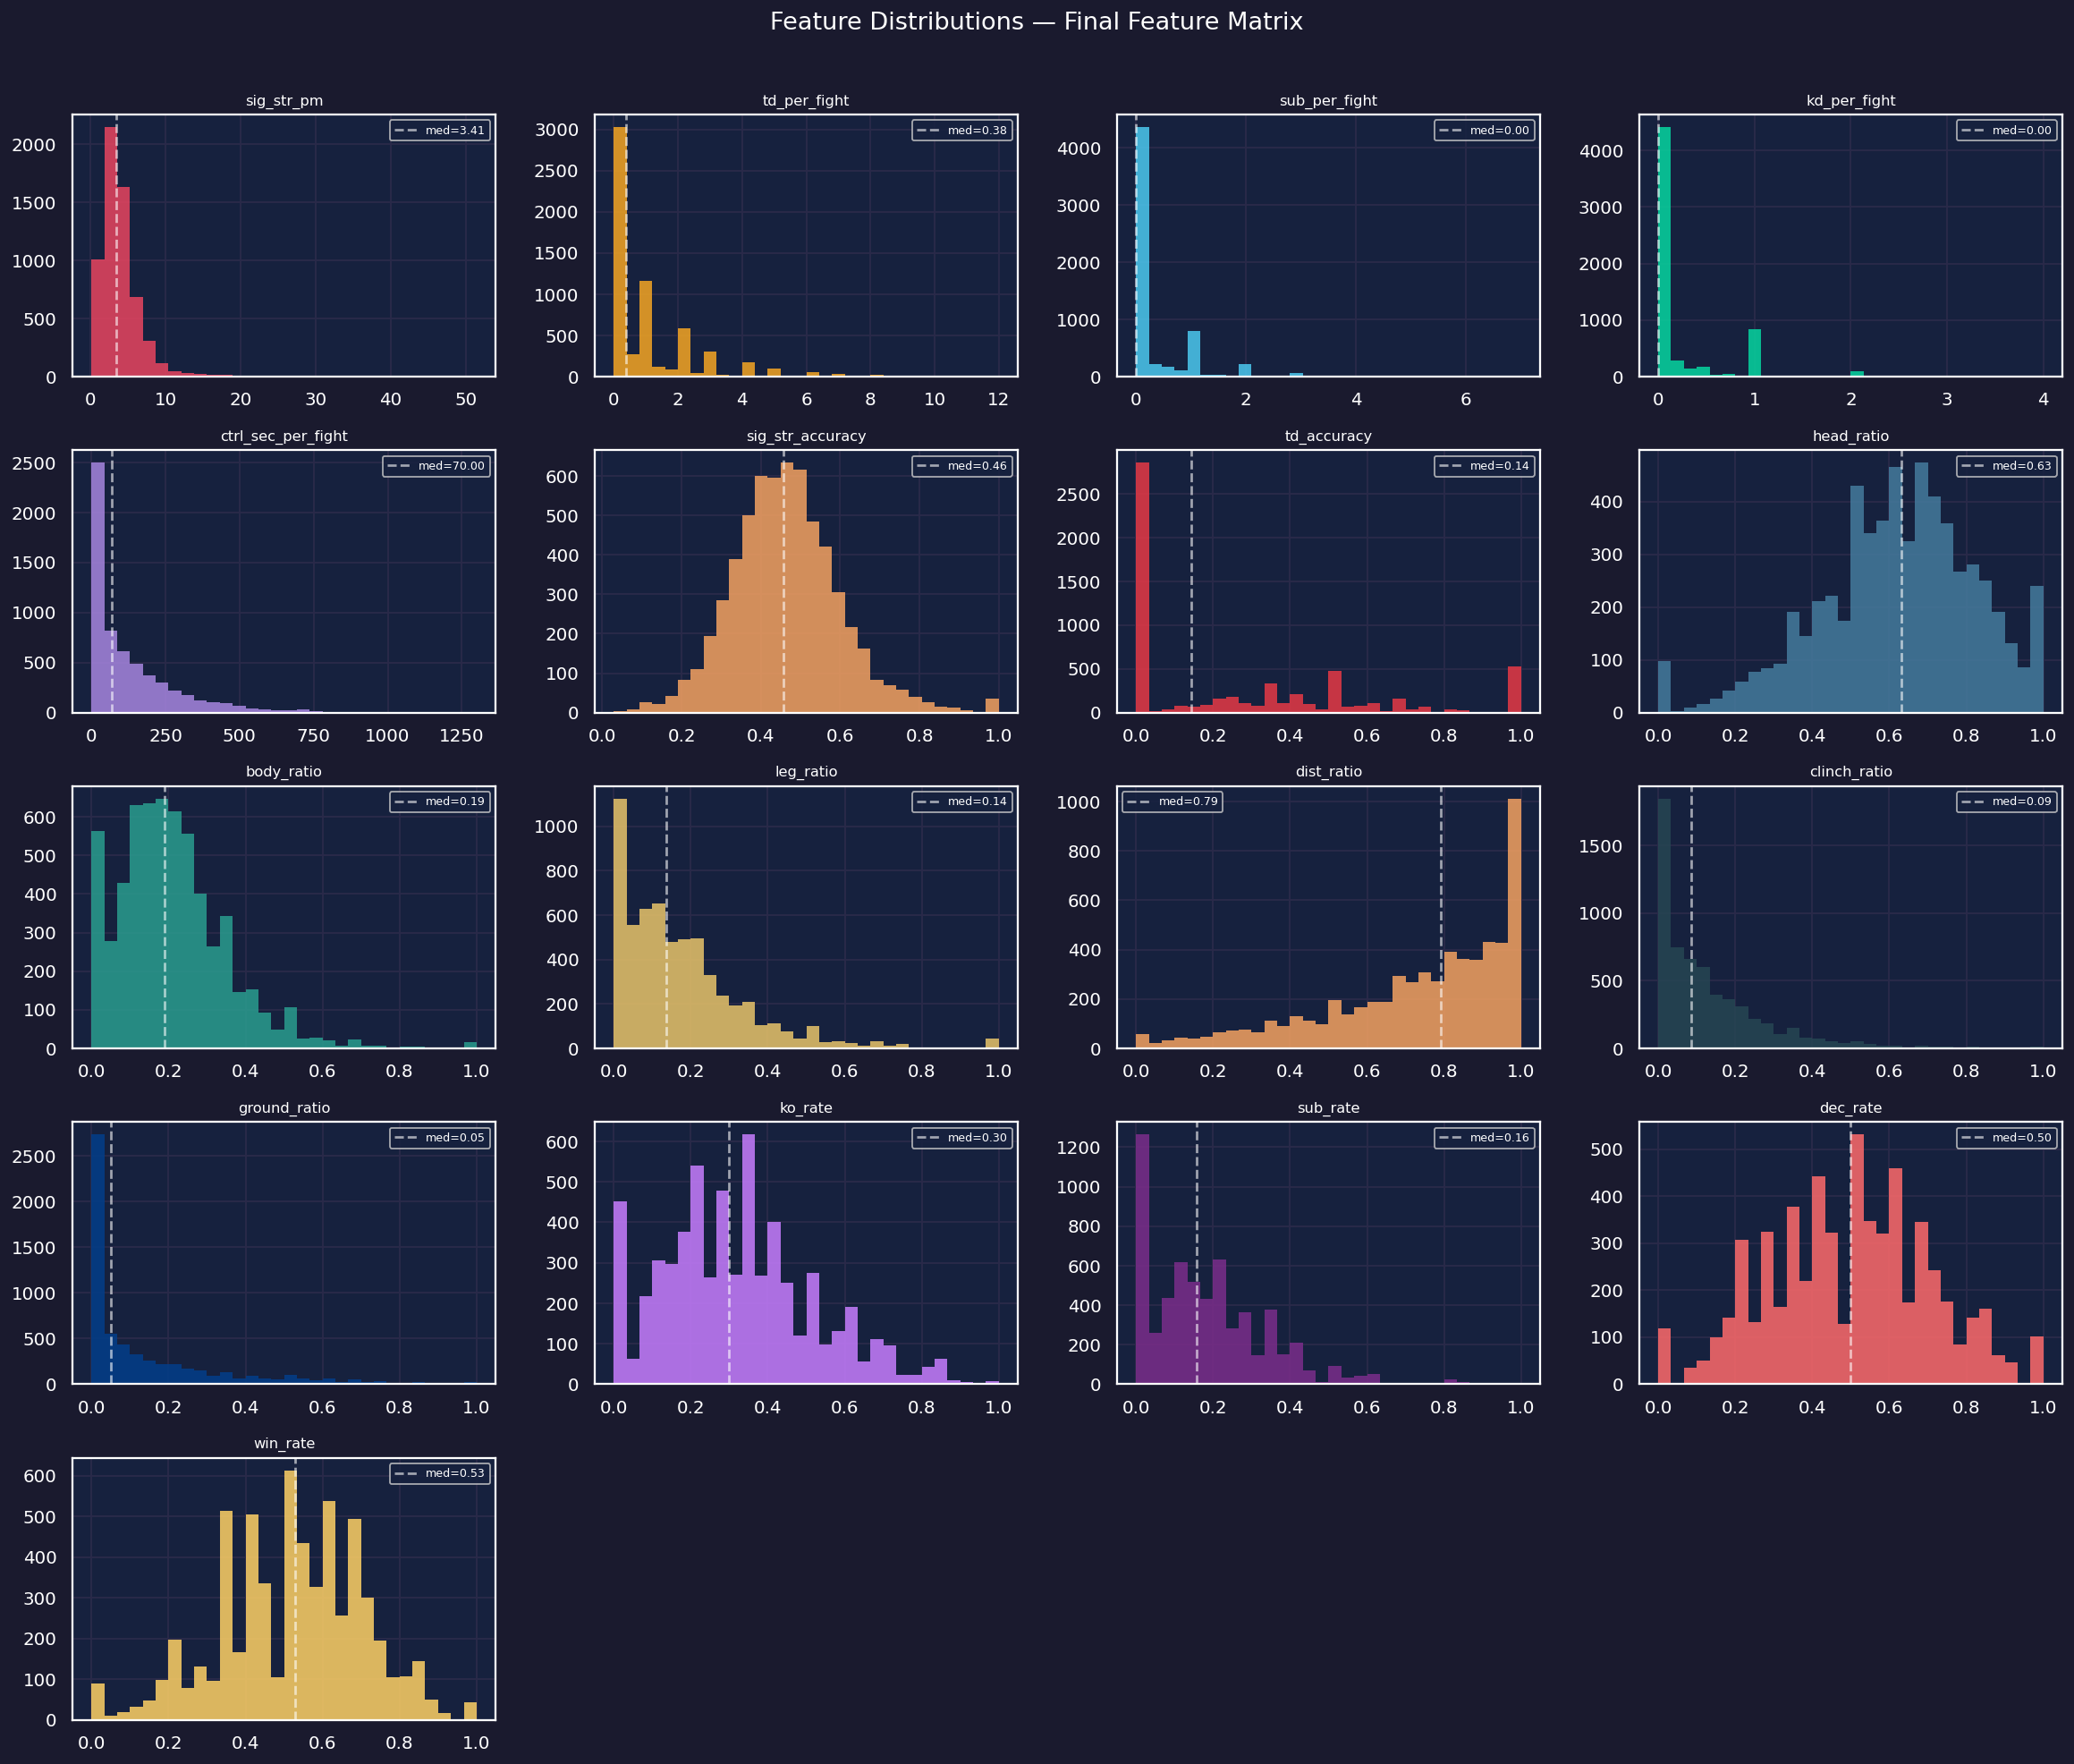

In [34]:
# ── Distribution of every feature ────────────────────────────
n_cols = 4
n_rows = int(np.ceil(len(STYLE_FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
fig.suptitle('Feature Distributions — Final Feature Matrix', fontsize=15, y=1.01)

colors = [ACCENT, GOLD, '#4cc9f0', '#06d6a0', '#a786df',
          '#f4a261', '#e63946', '#457b9d', '#2a9d8f',
          '#e9c46a', '#f4a261', '#264653', '#023e8a',
          '#c77dff', '#7b2d8b', '#ff6b6b', '#ffd166']

for i, (feat, color) in enumerate(zip(STYLE_FEATURES, colors)):
    ax = axes.flat[i]
    data = feature_matrix[feat].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.85, edgecolor='none')
    ax.set_title(feat, fontsize=9)
    ax.axvline(data.median(), color='white', linestyle='--', alpha=0.6,
               label=f'med={data.median():.2f}')
    ax.legend(fontsize=7)

# Hide empty subplots
for j in range(i + 1, len(axes.flat)):
    axes.flat[j].set_visible(False)

plt.tight_layout()
plt.show()

Visualisation des correlations entre les Features

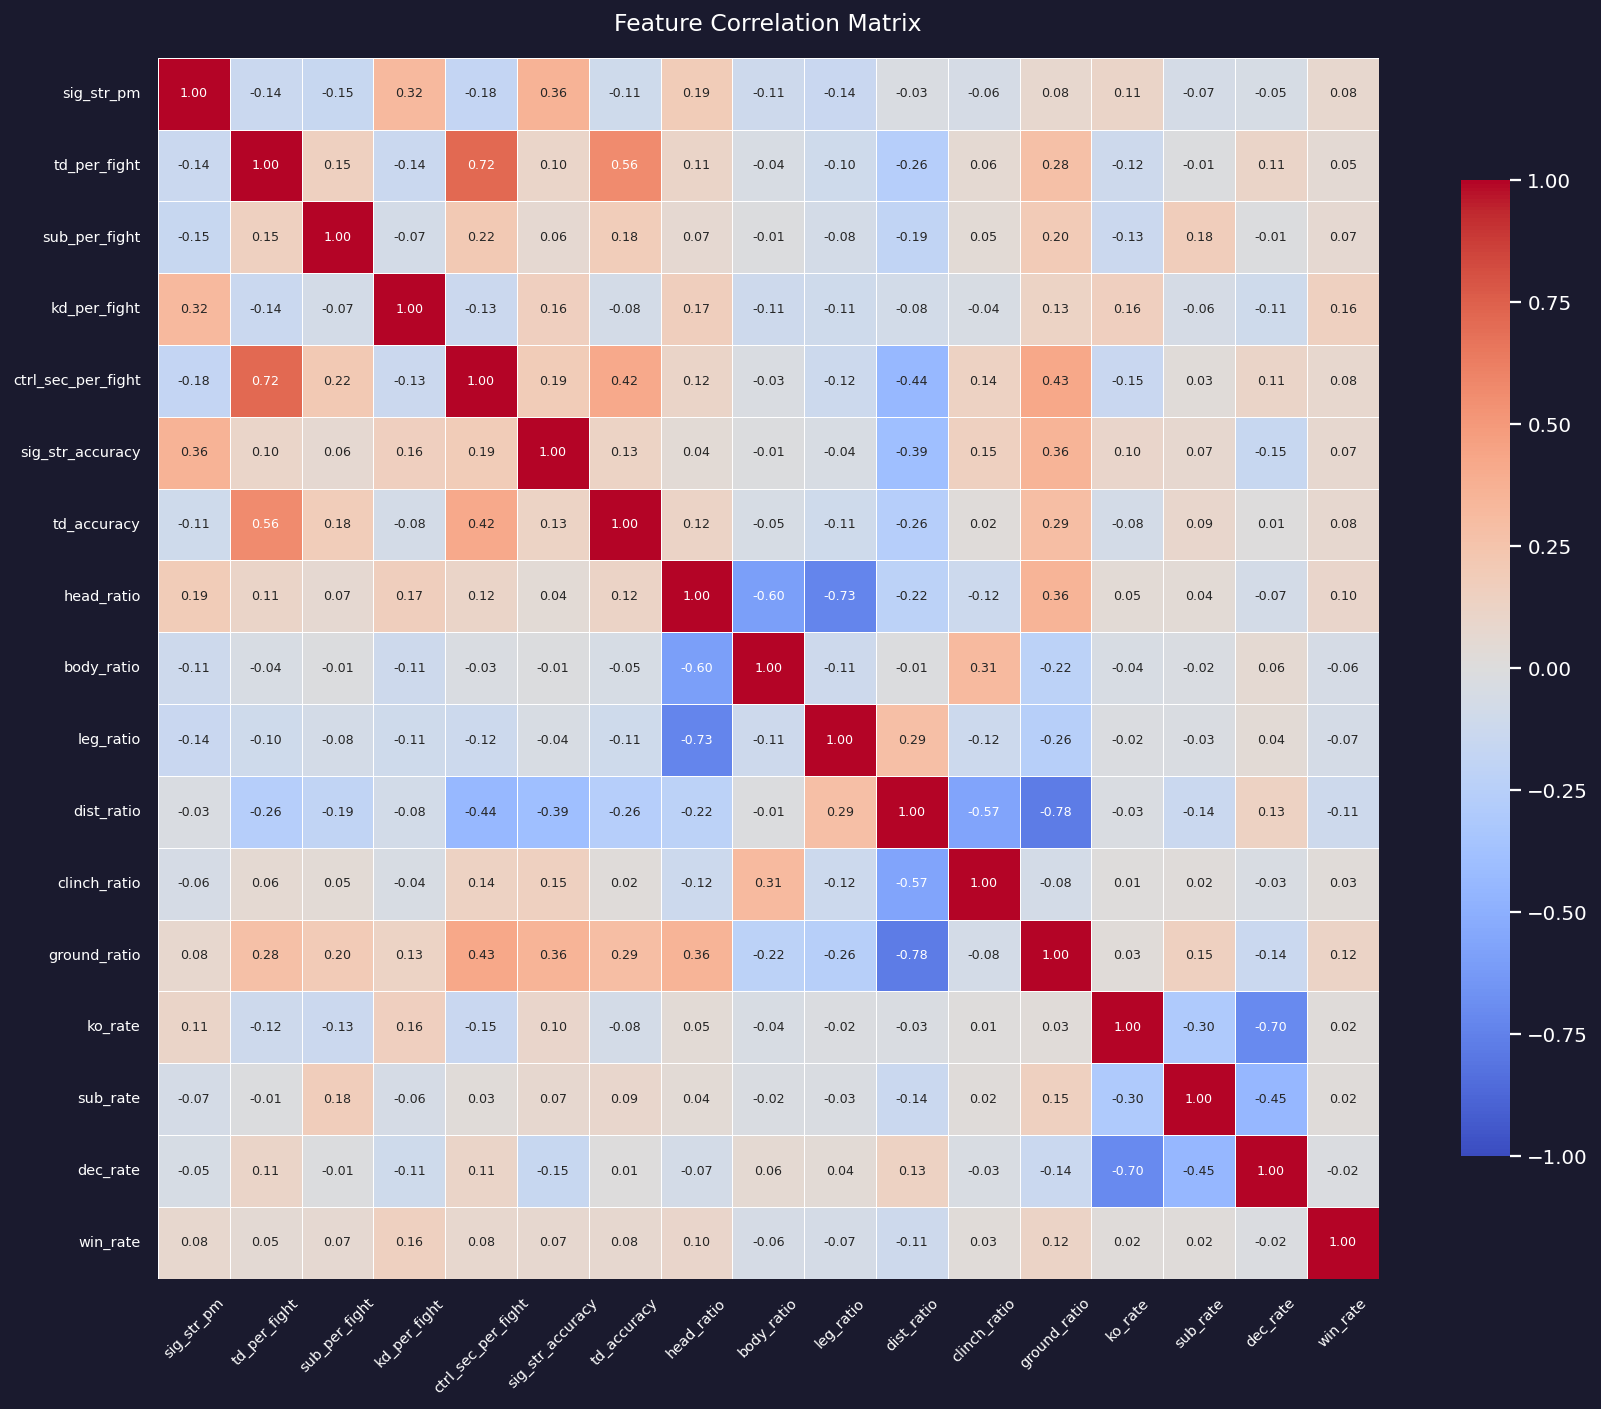

⚠️  High correlations (>0.75) — consider dropping one from each pair:
   dist_ratio  ↔  ground_ratio  :  -0.78


In [35]:
# ── Correlation heatmap of final features ────────────────────
corr = feature_matrix[STYLE_FEATURES].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0, ax=ax,
    square=True, linewidths=0.3,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 7}
)
ax.set_title('Feature Correlation Matrix', fontsize=13, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

# Flag high correlations (potential redundancy)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.75:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i,j],2)))

if high_corr:
    print('⚠️  High correlations (>0.75) — consider dropping one from each pair:')
    for a, b, v in high_corr:
        print(f'   {a}  ↔  {b}  :  {v}')
else:
    print('✅ No highly correlated feature pairs found')

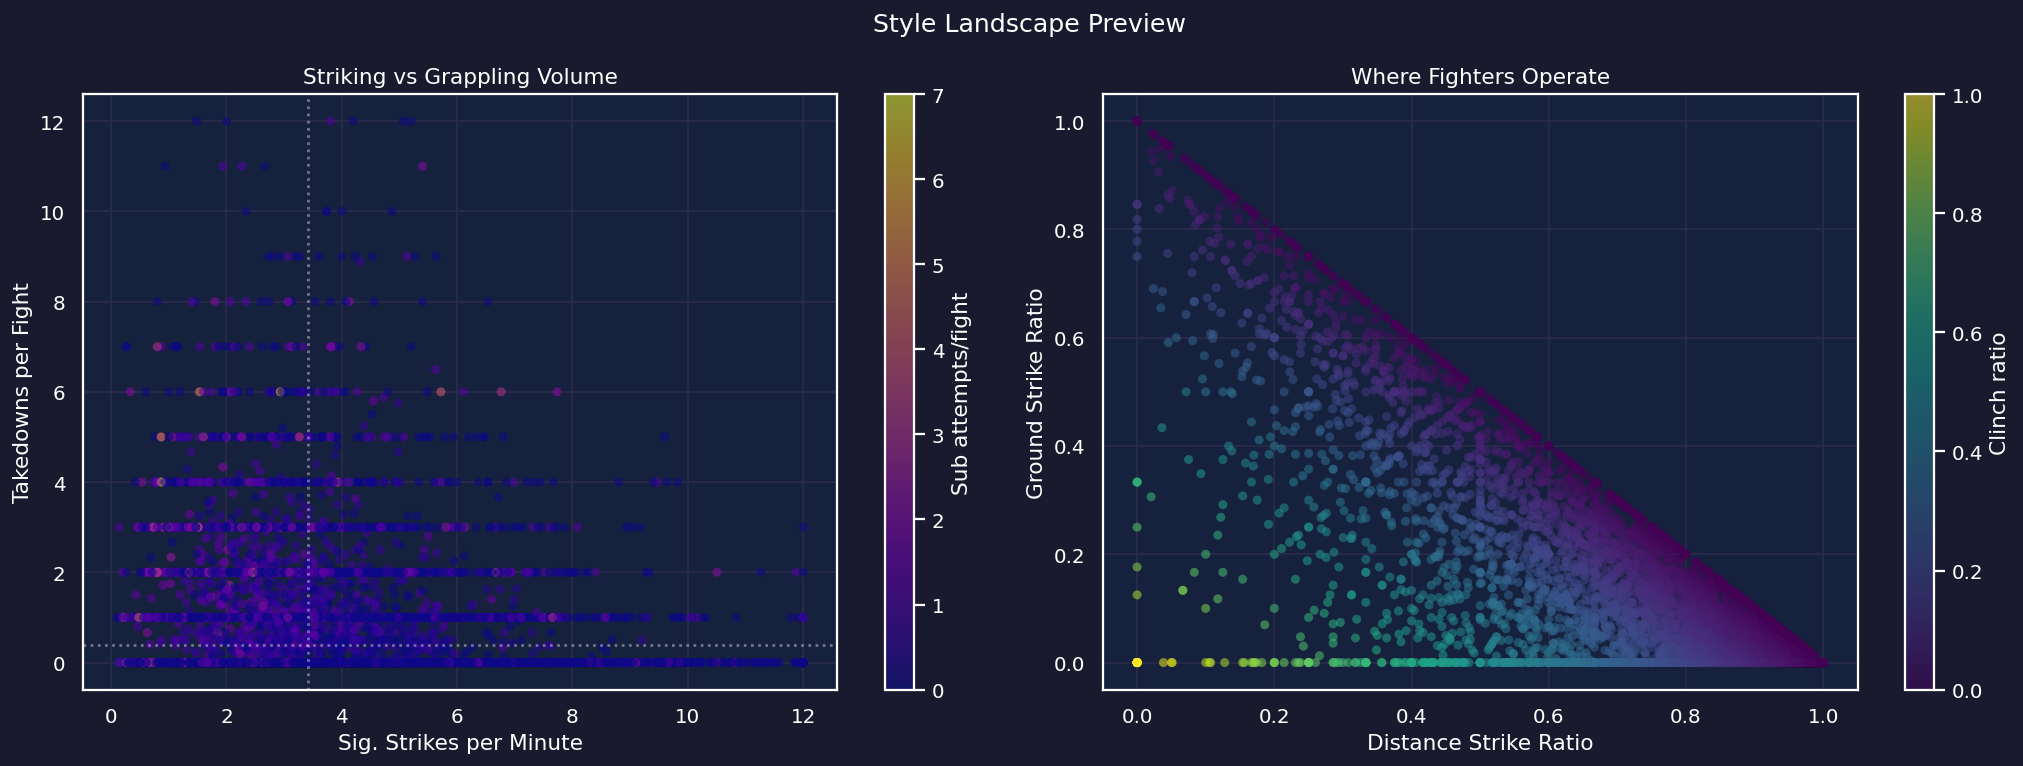

In [36]:
# ── Key scatter: striking vs grappling ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Style Landscape Preview', fontsize=14)

# Left: sig strikes vs takedowns (colored by submission tendency)
sc1 = axes[0].scatter(
    feature_matrix['sig_str_pm'].clip(0, 12),
    feature_matrix['td_per_fight'],
    c=feature_matrix['sub_per_fight'],
    cmap='plasma', alpha=0.55, s=25, edgecolors='none'
)
plt.colorbar(sc1, ax=axes[0]).set_label('Sub attempts/fight', color='white')
axes[0].set_xlabel('Sig. Strikes per Minute')
axes[0].set_ylabel('Takedowns per Fight')
axes[0].set_title('Striking vs Grappling Volume')
axes[0].axvline(feature_matrix['sig_str_pm'].median(), color='white', linestyle=':', alpha=0.4)
axes[0].axhline(feature_matrix['td_per_fight'].median(), color='white', linestyle=':', alpha=0.4)

# Right: ground ratio vs distance ratio (colored by clinch ratio)
sc2 = axes[1].scatter(
    feature_matrix['dist_ratio'],
    feature_matrix['ground_ratio'],
    c=feature_matrix['clinch_ratio'],
    cmap='viridis', alpha=0.55, s=25, edgecolors='none'
)
plt.colorbar(sc2, ax=axes[1]).set_label('Clinch ratio', color='white')
axes[1].set_xlabel('Distance Strike Ratio')
axes[1].set_ylabel('Ground Strike Ratio')
axes[1].set_title('Where Fighters Operate')

plt.tight_layout()
plt.show()

In [44]:
# ── Spotlight: look up a specific fighter ────────────────────
def lookup_fighter(name):
    mask = feature_matrix['Fighter_Name'].str.lower().str.contains(name.lower())
    result = feature_matrix[mask][['Fighter_Name','n_fights'] + STYLE_FEATURES]
    if result.empty:
        print(f'Fighter "{name}" not found')
    else:
        return result.round(3)

# Try a few known fighters as a sanity check
for name in ['Khabib', 'McGregor', 'Adesanya' , 'Jiri' , 'Makhachev' , 'Poirier' , 'Jon Jones' , 'Tsarukyan'  , 'Charles oliveira' , 'Moicano']:
    r = lookup_fighter(name)
    if r is not None:
        print(f'\n--- {name} ---')
        print(r.to_string(index=False))


--- Khabib ---
       Fighter_Name  n_fights  sig_str_pm  td_per_fight  sub_per_fight  kd_per_fight  ctrl_sec_per_fight  sig_str_accuracy  td_accuracy  head_ratio  body_ratio  leg_ratio  dist_ratio  clinch_ratio  ground_ratio  ko_rate  sub_rate  dec_rate  win_rate
Khabib Nurmagomedov         8       4.722         5.875            1.0           0.0             508.375             0.529        0.573       0.887       0.075      0.038       0.385         0.015         0.600    0.154     0.385     0.462     0.615
Khabib Nurmagomedov         1       3.600         5.000            0.0           0.0             390.000             0.415        0.455       0.741       0.167      0.093       0.815         0.037         0.148    0.000     0.167     0.667     0.167
Khabib Nurmagomedov         1       2.400         6.000            0.0           0.0             587.000             0.371        0.500       0.667       0.167      0.167       0.389         0.111         0.500    0.222     0.167     

# ***Sauvegarde du nouveau Dataset.***

In [45]:
OUTPUT_PATH = OUTPUT_DIR + 'fighter_features.csv'
feature_matrix.to_csv(OUTPUT_PATH, index=False)
print(f'✅ Saved to {OUTPUT_PATH}')

✅ Saved to /content/drive/MyDrive/Colab Notebooks/UFC Project/data/processed/fighter_features.csv


In [46]:
with mlflow.start_run(run_name='feature_engineering_v1'):

    # ── Parameters (decisions we made) ───────────────────────
    mlflow.log_param('min_fights_threshold',  MIN_FIGHTS)
    mlflow.log_param('n_style_features',      len(STYLE_FEATURES))
    mlflow.log_param('td_accuracy_fillna',    'zero_for_no_attempts')
    mlflow.log_param('stance_encoding',       'one_hot')
    mlflow.log_param('reach_height_dropped',  True)

    # ── Metrics (what we ended up with) ──────────────────────
    mlflow.log_metric('n_fighters',           len(feature_matrix))
    mlflow.log_metric('n_features',           len(STYLE_FEATURES))
    mlflow.log_metric('missing_values_total', feature_matrix[STYLE_FEATURES].isnull().sum().sum())
    mlflow.log_metric('mean_sig_str_pm',      feature_matrix['sig_str_pm'].mean().round(3))
    mlflow.log_metric('mean_td_per_fight',    feature_matrix['td_per_fight'].mean().round(3))

    # ── Artifact (the actual file) ────────────────────────────
    mlflow.log_artifact(OUTPUT_PATH)

    run_id = mlflow.active_run().info.run_id

print(f'✅ MLflow run logged  |  run_id: {run_id}')

✅ MLflow run logged  |  run_id: 9f542a65d68f4750a738c2311a0ff1d4
